# 03 Baseline Models
## 1. Load processed data
## 2. Basic cleaning
## 3. Feature construction
## 4. TF-IDF + Logistic Regression
## 5. LightGBM baseline
## 6. Evaluation
## 7. Result tables and figures

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path("..")
TRAIN_PATH = BASE_DIR / "data" / "processed" / "train_merged_20k.parquet"
VALID_PATH = BASE_DIR / "data" / "processed" / "valid_merged_10k.parquet"

train_df = pd.read_parquet(TRAIN_PATH)
valid_df = pd.read_parquet(VALID_PATH)

print("train shape:", train_df.shape)
print("valid shape:", valid_df.shape)

train_df.head()

train shape: (737762, 15)
valid shape: (375609, 15)


,impression_id,user_id,time,history,history_len,candidate_news_id,label,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,9,N55689,1,N55689,sports,football_nfl,"Charles Rogers, former Michigan State football...","Charles Rogers, the former Michigan State foot...",https://assets.msn.com/labs/mind/BBWAPO6.html,"[{""Label"": ""Charles Rogers (American football)...","[{""Label"": ""2003 NFL Draft"", ""Type"": ""U"", ""Wik..."
1,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,9,N35729,0,N35729,news,newsus,Porsche launches into second story of New Jers...,The Porsche went airborne off a median in Toms...,https://assets.msn.com/labs/mind/BBWyjM9.html,"[{""Label"": ""Porsche"", ""Type"": ""O"", ""WikidataId...","[{""Label"": ""Porsche"", ""Type"": ""O"", ""WikidataId..."
2,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,82,N20678,0,N20678,sports,more_sports,Bode Miller delivered his twin boys after midw...,Bode Miller added yet another impressive title...,https://assets.msn.com/labs/mind/BBWERWB.html,"[{""Label"": ""Bode Miller"", ""Type"": ""P"", ""Wikida...","[{""Label"": ""Bode Miller"", ""Type"": ""P"", ""Wikida..."
3,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,82,N39317,0,N39317,news,newspolitics,"Senior Trump official embellished résumé, had ...",State Dept. official Mina Chang claimed to be ...,https://assets.msn.com/labs/mind/BBWEmIj.html,"[{""Label"": ""Donald Trump"", ""Type"": ""P"", ""Wikid...","[{""Label"": ""Harvard Business School"", ""Type"": ..."
4,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,82,N58114,0,N58114,autos,autosnews,2020 Ford Explorer launch hardly went accordin...,None,https://assets.msn.com/labs/mind/BBWEGnz.html,"[{""Label"": ""Ford Explorer"", ""Type"": ""V"", ""Wiki...",[]


In [2]:
required_cols = [
    "candidate_news_id",
    "label",
    "title",
    "abstract",
    "category",
    "subcategory",
    "history_len"
]

for col in required_cols:
    print(col, "->", col in train_df.columns)

candidate_news_id -> True
label -> True
title -> True
abstract -> True
category -> True
subcategory -> True
history_len -> True


In [3]:
print("train CTR:", train_df["label"].mean())
print("valid CTR:", valid_df["label"].mean())

train CTR: 0.040519842442413675
valid CTR: 0.0407791080618409


In [4]:
plt.rcParams["figure.dpi"] = 140
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

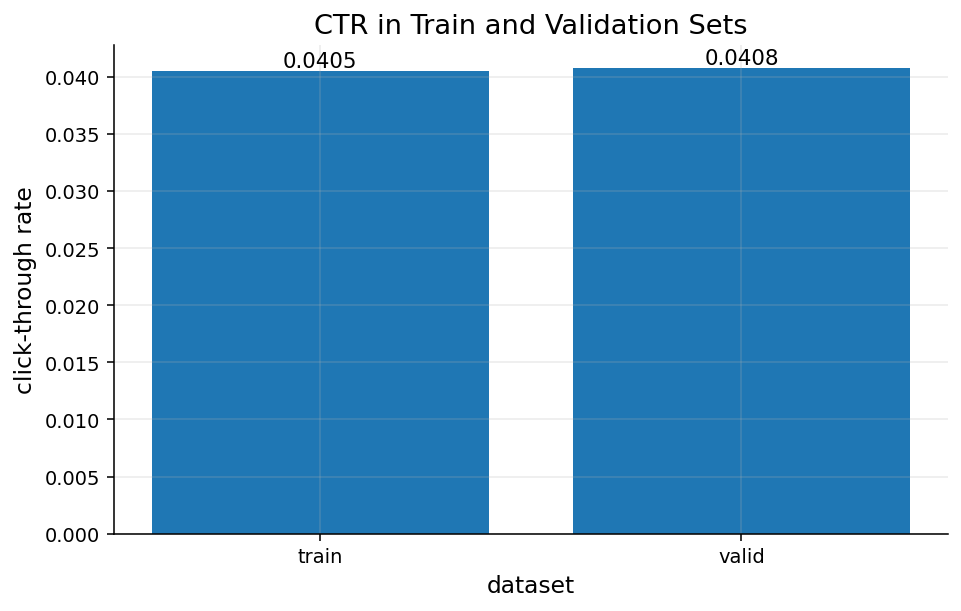

In [5]:
ctr_df = pd.DataFrame({
    "dataset": ["train", "valid"],
    "ctr": [train_df["label"].mean(), valid_df["label"].mean()]
})

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(ctr_df["dataset"], ctr_df["ctr"])
ax.set_title("CTR in Train and Validation Sets")
ax.set_xlabel("dataset")
ax.set_ylabel("click-through rate")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f"{height:.4f}",
            ha="center", va="bottom")

plt.tight_layout()
plt.show()